# 完整的模型测试套路

In [10]:
from PIL import Image
import torchvision
import torch
from torch import nn

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 用GPU的方法2
device

device(type='cuda')

- 获取输入图像

In [ ]:
image_path = "./images/dog.png" # 这是网上随便找的图片

In [ ]:
image = Image.open(image_path)

- 对输入图像进行处理

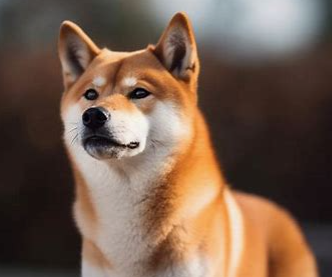

In [ ]:
image = image.convert('RGB') # 注意这个模型输入是RGB三通道
image

In [15]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((32, 32)),
    torchvision.transforms.ToTensor(),
])

In [ ]:
image = transform(image) # 输入大小变为32×32
image.shape

torch.Size([3, 32, 32])

In [16]:
image = torch.reshape(image, (1, 3, 32, 32))
image.shape

torch.Size([1, 3, 32, 32])

- 模型的定义

In [11]:
class model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 32, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2, stride=1),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64*4*4, 64),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        output = self.seq(x)
        return output

- 加载本地模型

In [ ]:
my_model = torch.load("my_model_4.pth", weights_only=False) # 这是“完整的模型训练套路”这一节保存的模型，由于保存的时候是GPU训练，验证也要用GPU
print(my_model)

model(
  (seq): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1024, out_features=64, bias=True)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


- 验证

In [ ]:
my_model = my_model.to(device) # 由于模型保存的时候是GPU训练，验证也要用GPU
image = image.to(device)

In [26]:
my_model.eval() # 打开验证模式
with torch.no_grad(): # 节约内存
    output = my_model(image)

output

tensor([[-1.7748, -6.6650,  2.7518,  3.1453,  0.2610,  4.5679,  2.8672,  1.1749,
         -3.9156, -2.7506]], device='cuda:0')

In [28]:
output.argmax(1)

tensor([5], device='cuda:0')

*证明预测的是5号类别（类别号从0开始）* \
*根据测试集资料，5号类别正是“狗”，正确！*